<a href="https://colab.research.google.com/github/Carereen/image-processing/blob/main/Assignment6_Sec2_6853800122.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

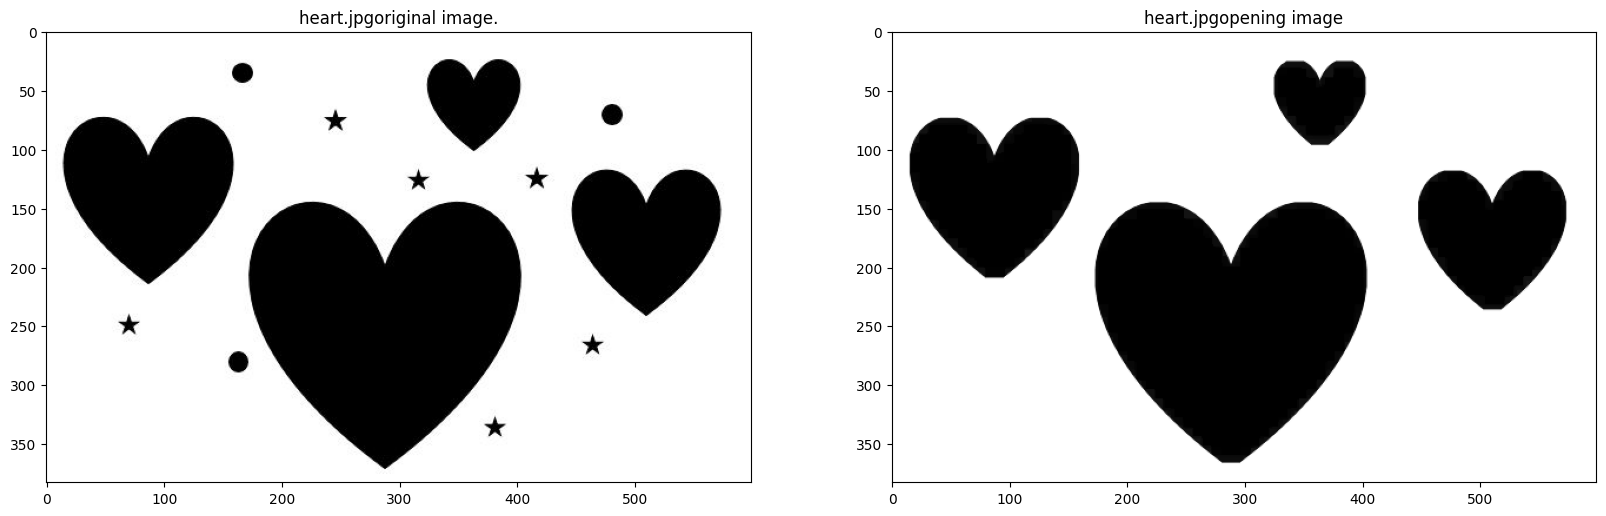

In [ ]:
path = '/content/drive/MyDrive/2568-term2/image/Lab6-Image/'
image_name = 'heart.jpg'
image = cv2.imread(path + image_name)

if image is None:
  print(f"Image file not found. Please check the path:{path + image} .")
  sys.exit()

kernel = np.ones((15, 15), np.uint8)

image_opening = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

fig = plt.figure(figsize = (20, 20))

plt.subplot(1, 2, 1), plt.imshow(image)
plt.title(image_name + 'original image.')

plt.subplot(1, 2, 2), plt.imshow(image_opening)
plt.title(image_name +'opening image')
plt.show()

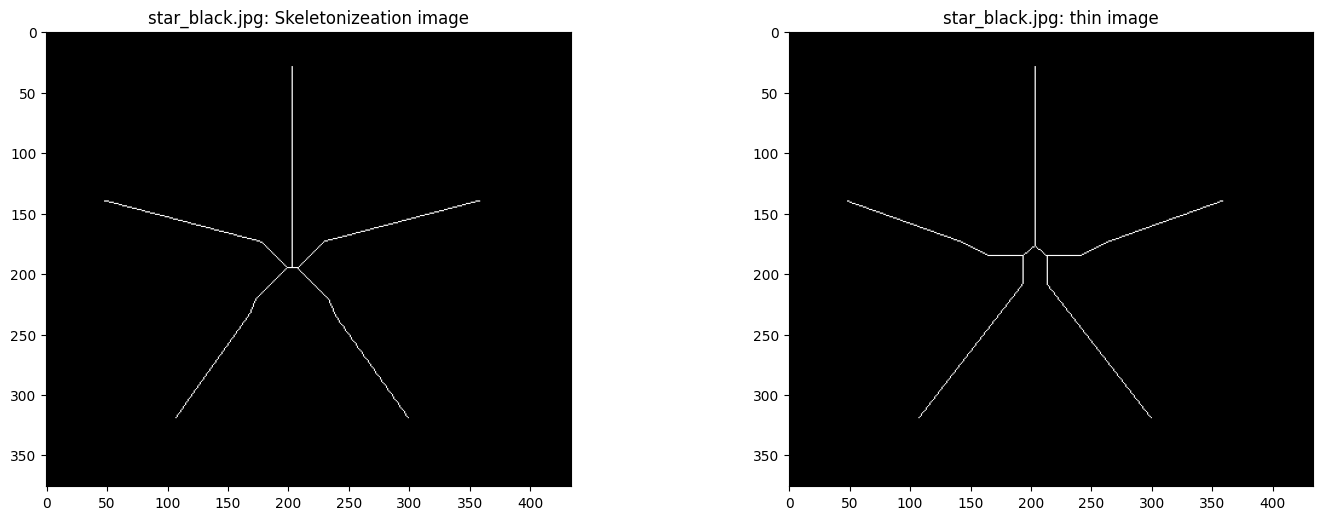

In [ ]:
from skimage.morphology import skeletonize, thin
image_name = 'star_black.jpg'
img = cv2.imread(path + image_name, 0)

if img is None:
  print(f"Image file not file. Please check the path: {path + image_name} .")
  sys.exit()

image = img < 200
skeleton = skeletonize(image)
thin = thin(image)

fig = plt.figure(figsize = (15, 10))

plt.subplot(2, 2, 1), plt.imshow(skeleton, cmap = 'gray')
plt.title(image_name + ': Skeletonizeation image')

plt.subplot(2, 2, 2), plt.imshow(thin, cmap = 'gray')
plt.title(image_name + ': thin image')
fig.tight_layout()
plt.show()

Number of object is 13


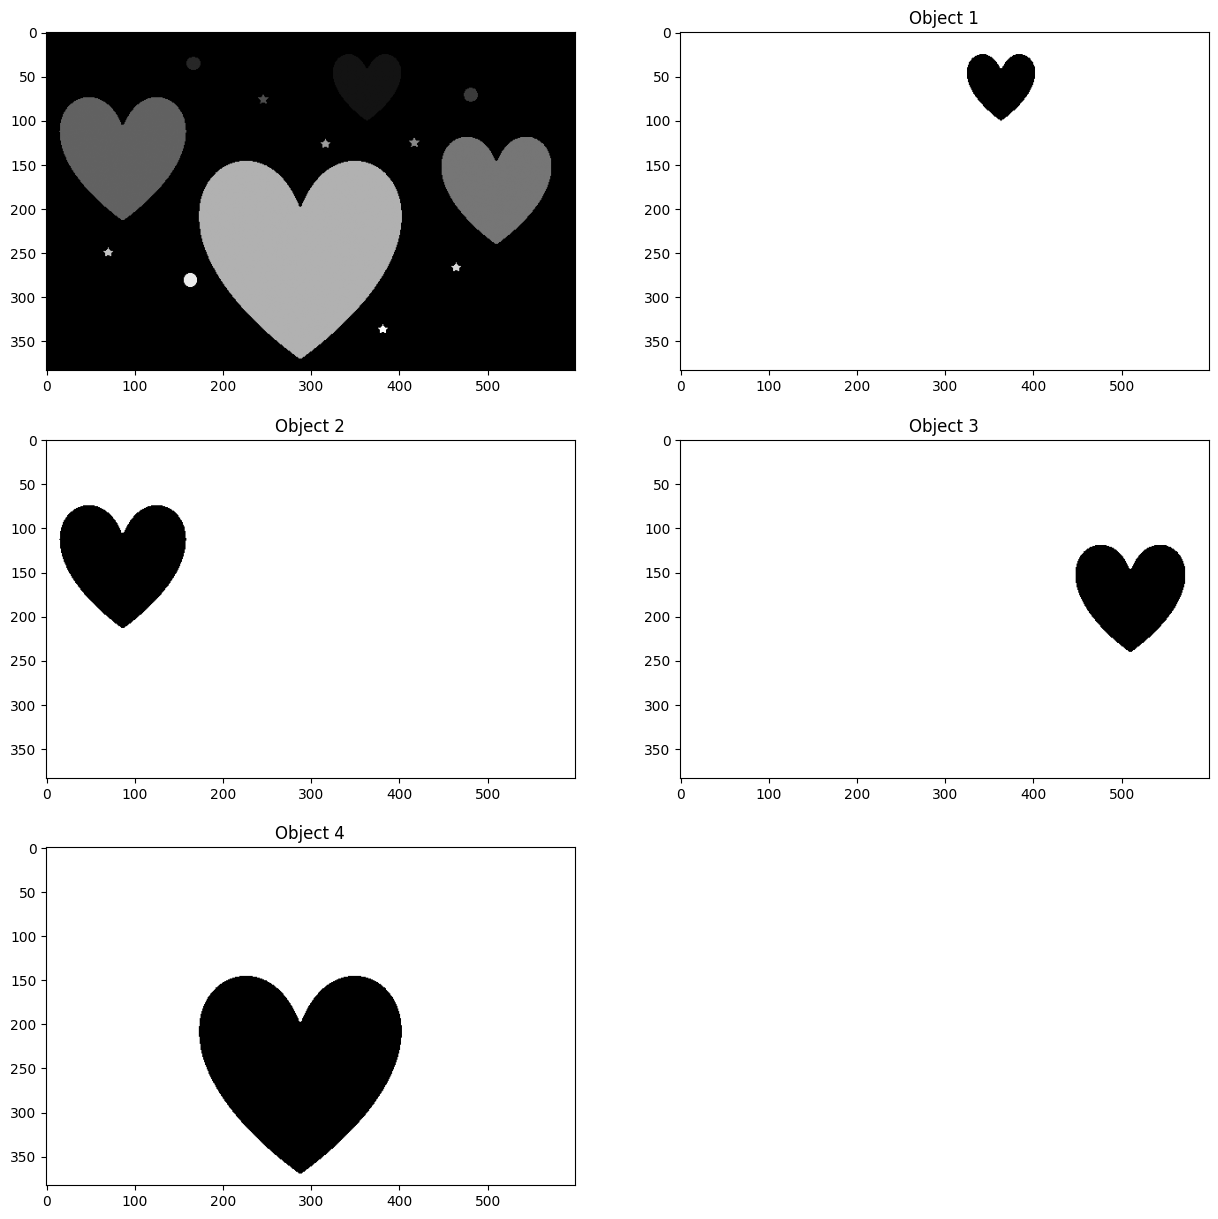

In [ ]:
from scipy import ndimage
import sys

image_name = 'heart.jpg'
image = cv2.imread(path + image_name, 0)

if image is None:
  print(f"Image file not found. Please check the path: {path + image_name} .")
  sys.exit()

image_array = np.asarray(image)
image_filter = ndimage.gaussian_filter(image_array, 1.0)

# object = white | blackgroud = black ใช้ <
labeled, nr_objects = ndimage.label(image_filter < 50)
print("Number of object is {}". format(nr_objects))

fig = plt.figure(figsize = (15, 15))
plt.subplot(3, 2, 1), plt.imshow(labeled, cmap = 'gray')

labels = np.unique(labeled)
# print(labels)

image = labeled == labels[1]
image_new1 = 255 - image
plt.subplot(3, 2, 2), plt.imshow(image_new1, cmap = 'gray'),
plt.title('Object 1')

image = labeled == labels[5]
image_new2 = 255 - image
plt.subplot(3, 2, 3), plt.imshow(image_new2, cmap = 'gray'),
plt.title('Object 2')

image = labeled == labels[6]
image_new2 = 255 - image
plt.subplot(3, 2, 4), plt.imshow(image_new2, cmap = 'gray'),
plt.title('Object 3')

image = labeled == labels[9]
image_new2 = 255 - image
plt.subplot(3, 2, 5), plt.imshow(image_new2, cmap = 'gray'),
plt.title('Object 4')
plt.show()